# Marketing Funnel Analysis (EDA + Business Findings)

**Grain:** one row per `mql_id` (a marketing-qualified lead). **Input:** `cleaned_marketing_funnel_master_table.csv`
(from `data_cleaning/clean_marketing_funnel_table.ipynb`; falls back to the raw master automatically).

A lead is **converted** (`is_converted_flag = True`) if it has a matching closed deal, i.e. it became a seller.
Deal-side fields (`business_segment`, `lead_type`, `business_type`, `sdr_id`, `sr_id`, `won_date`, ...) only
exist for converted leads by construction — a missing value there means "this lead never converted", not
"data is dirty". Within the converted rows themselves, the cleaning notebook found and fixed real issues:
`declared_monthly_revenue` / `declared_product_catalog_size` were 0 for ~95% of deals (an unanswered-survey
placeholder, not a genuine zero) and are now `NaN` with explicit `has_declared_revenue` /
`has_declared_catalog_size` flags; `has_company` / `has_gtin` are now proper booleans; `lead_behaviour_profile`
is normalized to a primary label plus a `multi_behaviour_flag`; and the one deal with a negative
`time_to_win_days` is flagged via `time_to_win_valid_flag` rather than silently included in any average.

This single notebook consolidates the funnel EDA: data quality, top-of-funnel channel performance,
who converts (segment / lead type / business type), how long it takes to close, and where the seller
pipeline is strongest versus leaking — feeding the same "grow the marketplace" story as the customer
and seller analyses, but from the acquisition side.


## 0. Setup and data load

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', '{:,.2f}'.format)

# Shared palette for the "focused" charts (exploratory charts keep their original colours)
PALETTE = dict(navy='#1b2a4a', red='#d1495b', green='#2a9d8f',
               amber='#e9c46a', orange='#e76f51', grey='#8d99ae')

# --- Locate the cleaned table (preferred) or fall back to the raw master ---
here = Path.cwd()
roots = [here, here.parent, here / 'data-visualization', here.parent / 'data-visualization',
         here / 'data_cleaning', here.parent / 'data_cleaning']
def _find(name):
    return next((r / name for r in roots if (r / name).exists()), None)

cleaned = _find('cleaned_marketing_funnel_master_table.csv')
if cleaned is not None:
    leads = pd.read_csv(cleaned, parse_dates=['first_contact_date', 'won_date'])
    print('Loaded CLEANED marketing funnel table:', cleaned)
else:
    raw = _find('marketing_funnel_master_table.csv')
    leads = pd.read_csv(raw, parse_dates=['first_contact_date', 'won_date'])
    leads['has_declared_revenue'] = leads['declared_monthly_revenue'].notna() & leads['declared_monthly_revenue'].ne(0)
    leads['has_declared_catalog_size'] = leads['declared_product_catalog_size'].notna() & leads['declared_product_catalog_size'].ne(0)
    leads['time_to_win_valid_flag'] = leads['time_to_win_days'].isna() | leads['time_to_win_days'].ge(0)
    print('Cleaned table not found - loaded raw master with flags:', raw)

# --- Figures render INLINE by default (matches the rest of the repo, no outputs/ folder). ---
# Flip SAVE_FIGURES to True to ALSO export PNGs (e.g. when building the slide deck / report).
SAVE_FIGURES = False
repo_root = here.parent if here.name == 'data-visualization' else here
fig_dir = repo_root / 'outputs' / 'figures'
def save_fig(name):
    if SAVE_FIGURES:
        fig_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(fig_dir / name, dpi=130)

conversion_rate = leads['is_converted_flag'].mean()
print(f'Leads: {len(leads):,} rows x {leads.shape[1]} columns '
      f'| overall conversion rate {conversion_rate:.1%}')
leads.head()


Loaded CLEANED marketing funnel table: E:\DVDProject\ecommerce-visual-analytics\data-visualization\cleaned_marketing_funnel_master_table.csv
Leads: 8,000 rows x 26 columns | overall conversion rate 10.5%


,mql_id,first_contact_date,landing_page_id,origin,seller_id,sdr_id,sr_id,won_date,business_segment,lead_type,...,declared_monthly_revenue,is_converted_flag,time_to_win_days,lead_age_days,days_to_first_contact_missing_flag,won_date_missing_flag,has_declared_revenue,has_declared_catalog_size,multi_behaviour_flag,time_to_win_valid_flag
0,dac32acd4db4c29c230538b72f8dd87d,2018-02-01,88740e65d5d6b056e0cda098e1ea6313,social,NaN,NaN,NaN,NaT,NaN,NaN,...,NaN,False,NaN,3111,False,True,False,False,False,True
1,8c18d1de7f67e60dbd64e3c07d7e9d5d,2017-10-20,007f9098284a86ee80ddeb25d53e0af8,paid_search,NaN,NaN,NaN,NaT,NaN,NaN,...,NaN,False,NaN,3215,False,True,False,False,False,True
2,b4bc852d233dfefc5131f593b538befa,2018-03-22,a7982125ff7aa3b2054c6e44f9d28522,organic_search,NaN,NaN,NaN,NaT,NaN,NaN,...,NaN,False,NaN,3062,False,True,False,False,False,True
3,6be030b81c75970747525b843c1ef4f8,2018-01-22,d45d558f0daeecf3cccdffe3c59684aa,email,NaN,NaN,NaN,NaT,NaN,NaN,...,NaN,False,NaN,3121,False,True,False,False,False,True
4,5420aad7fec3549a85876ba1c529bd84,2018-02-21,b48ec5f3b04e9068441002a19df93c6c,organic_search,2c43fb513632d29b3b58df74816f1b06,a8387c01a09e99ce014107505b92388c,4ef15afb4b2723d8f3d81e51ec7afefe,2018-02-26 19:58:54,pet,online_medium,...,NaN,True,5.00,3091,False,False,False,False,False,True


## 1. Data quality & coverage

Deal-side columns are populated **only** for converted leads by construction of the join — that's
expected, not a defect. The real cleaning (recoding the fake-zero `declared_monthly_revenue` /
`declared_product_catalog_size`, fixing `has_company` / `has_gtin` dtypes, normalizing
`lead_behaviour_profile`, flagging the one invalid `time_to_win_days`) already happened in
`data_cleaning/clean_marketing_funnel_table.ipynb`. The audit below is a final check on the table
as loaded here.

In [3]:
audit = pd.DataFrame({
    'data_type': leads.dtypes.astype(str),
    'missing_values': leads.isna().sum(),
    'missing_rate': leads.isna().mean(),
    'distinct_values': leads.nunique(),
})

print(f'Lead rows: {len(leads):,}')
print(f"Duplicate mql_id: {leads['mql_id'].duplicated().sum()}")
print(f'Converted leads: {leads["is_converted_flag"].sum():,} ({conversion_rate:.1%})')
audit.sort_values('missing_rate', ascending=False)


Lead rows: 8,000
Duplicate mql_id: 0
Converted leads: 842 (10.5%)


,data_type,missing_values,missing_rate,distinct_values
declared_monthly_revenue,float64,7955,0.99,26
has_company,object,7937,0.99,2
has_gtin,object,7936,0.99,2
average_stock,str,7934,0.99,6
declared_product_catalog_size,float64,7931,0.99,33
lead_behaviour_profile,str,7335,0.92,4
business_type,str,7168,0.90,3
lead_type,str,7164,0.90,8
business_segment,str,7159,0.89,33
won_date,datetime64[us],7158,0.89,824


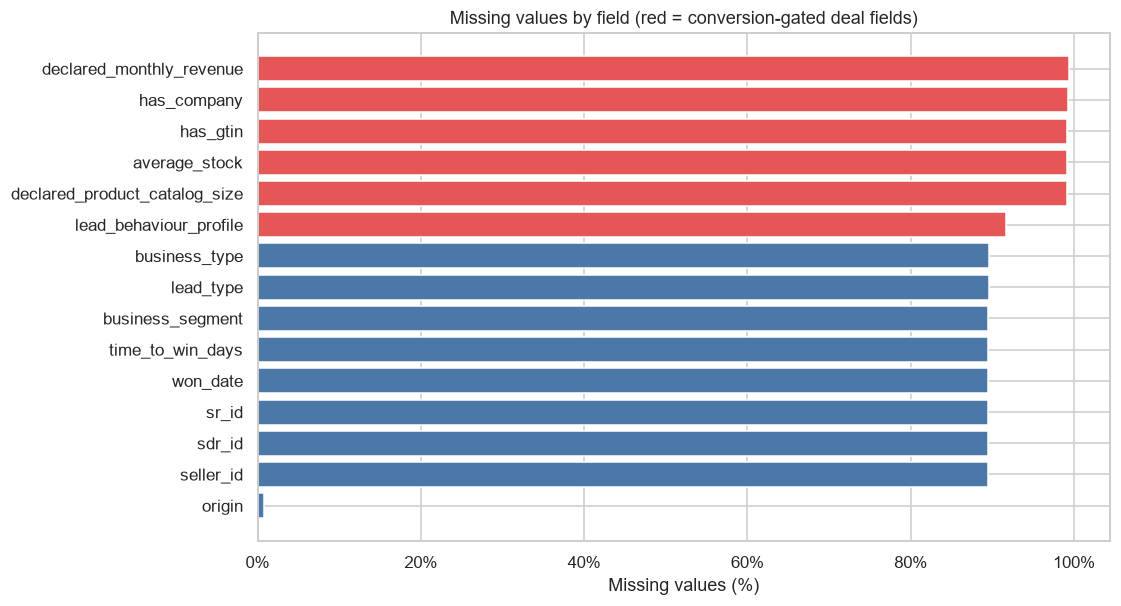

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
missing = audit.query('missing_rate > 0').sort_values('missing_rate')
colors = ['#4c78a8' if v < 0.9 else '#e45756' for v in missing['missing_rate']]
ax.barh(missing.index, missing['missing_rate'] * 100, color=colors)
ax.set(title='Missing values by field (red = conversion-gated deal fields)',
       xlabel='Missing values (%)', ylabel='')
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
save_fig('marketing_missing_values.png')
plt.show()


In [6]:
leads.isna().sum()

mql_id                                   0
first_contact_date                       0
landing_page_id                          0
origin                                  60
seller_id                             7158
sdr_id                                7158
sr_id                                 7158
won_date                              7158
business_segment                      7159
lead_type                             7164
lead_behaviour_profile                7335
has_company                           7937
has_gtin                              7936
average_stock                         7934
business_type                         7168
declared_product_catalog_size         7931
declared_monthly_revenue              7955
is_converted_flag                        0
time_to_win_days                      7158
lead_age_days                            0
days_to_first_contact_missing_flag       0
won_date_missing_flag                    0
has_declared_revenue                     0
has_declare

In [4]:
# --- Remaining known items, already flagged (not fixed further) by the cleaning notebook ---
missing_origin = leads['origin'].isna().sum()
invalid_time_to_win = (~leads['time_to_win_valid_flag']).sum()
declared_revenue_coverage = leads['has_declared_revenue'].sum()

print(f"Leads with missing 'origin': {missing_origin} ({missing_origin/len(leads):.2%})")
print(f'Deals with an invalid (negative) time_to_win_days: {invalid_time_to_win}')
print(f'Converted deals with a usable declared_monthly_revenue: {declared_revenue_coverage}')
leads.loc[~leads['time_to_win_valid_flag'],
          ['mql_id', 'first_contact_date', 'won_date', 'time_to_win_days']]


Leads with missing 'origin': 60 (0.75%)
Deals with an invalid (negative) time_to_win_days: 1
Converted deals with a usable declared_monthly_revenue: 45


,mql_id,first_contact_date,won_date,time_to_win_days
6357,b91cf8812365f50ff4bda4bcd6206b05,2018-03-08,2018-03-06 19:38:55,-2.00


`origin` is still missing for 60 leads (0.75%) — small enough to leave as `NaN` / group into
'unknown' rather than impute. `time_to_win_valid_flag` marks the one deal with a negative time-to-win
(won before first contact was logged) so it can be excluded from time-to-win statistics without being
dropped from the table. Only 45 of 842 converted deals (5.3%) have a usable, non-placeholder
`declared_monthly_revenue` — any revenue-based finding below should be read as directional, not as
representative of all converted sellers.

## 2. Funnel shape & channel performance (origin)

The first question for any funnel: which channels bring in leads, and which channels actually
produce sellers? Volume and conversion rate tell very different stories per channel.

**Exploratory — lead volume by origin**

C:\Users\anshr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\anshr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\anshr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


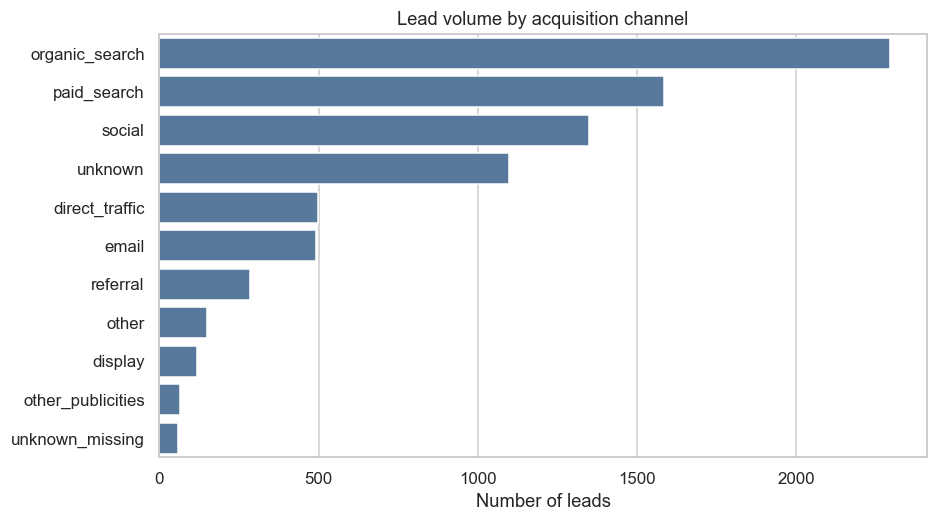

In [5]:
origin_counts = leads['origin'].fillna('unknown_missing').value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=origin_counts.values, y=origin_counts.index, color='#4c78a8', ax=ax)
ax.set(title='Lead volume by acquisition channel', xlabel='Number of leads', ylabel='')
save_fig('marketing_origin_volume.png')
plt.show()


**Focused — conversion rate by origin (volume-weighted)**

,leads,conversions,conversion_rate
origin,,,
unknown_missing,60,14,0.23
unknown,1099,179,0.16
paid_search,1586,195,0.12
organic_search,2296,271,0.12
direct_traffic,499,56,0.11
referral,284,24,0.08
social,1350,75,0.06
display,118,6,0.05
other_publicities,65,3,0.05


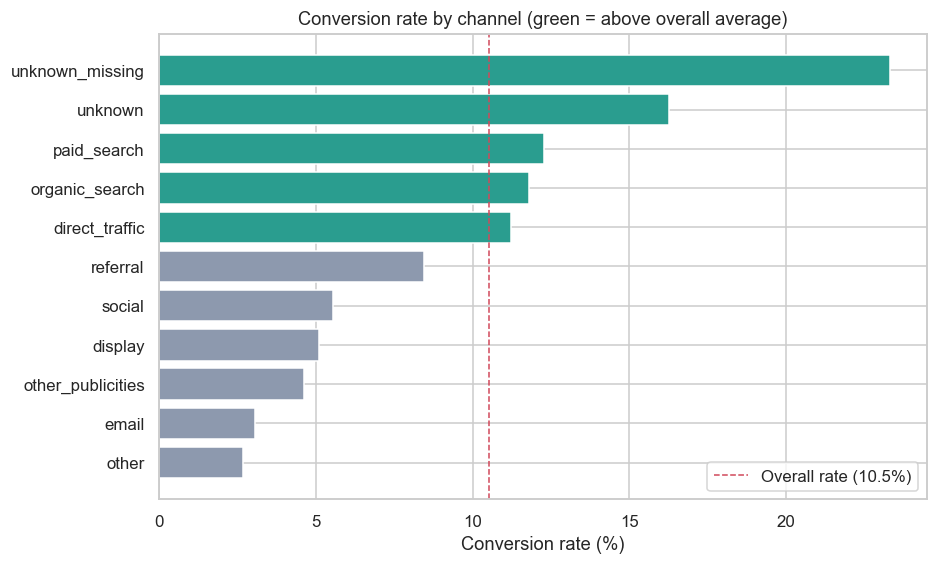

In [6]:
origin_view = (leads.assign(origin=leads['origin'].fillna('unknown_missing'))
    .groupby('origin')
    .agg(leads=('mql_id', 'count'), conversions=('is_converted_flag', 'sum'),
         conversion_rate=('is_converted_flag', 'mean'))
    .sort_values('conversion_rate', ascending=False))
display(origin_view)

fig, ax = plt.subplots(figsize=(9, 5.5))
order = origin_view.sort_values('conversion_rate')
colors = [PALETTE['green'] if r >= conversion_rate else PALETTE['grey'] for r in order['conversion_rate']]
ax.barh(order.index, order['conversion_rate'] * 100, color=colors)
ax.axvline(conversion_rate * 100, color=PALETTE['red'], ls='--', lw=1,
           label=f'Overall rate ({conversion_rate:.1%})')
ax.set(title='Conversion rate by channel (green = above overall average)',
       xlabel='Conversion rate (%)', ylabel='')
ax.legend()
save_fig('marketing_origin_conversion.png')
plt.show()


**Reading it together:** `organic_search` and `paid_search` bring in the most leads, but the
channel with the best conversion rate is `unknown` (untracked referral sources), followed by
`paid_search`. Channels with real volume but weak conversion — `social` and `email` — are candidates
for either better lead qualification at the top of the funnel or a different follow-up motion, since
they're not a small-sample fluke (both have 300+ leads).

## 3. Who converts: business segment & lead type

These fields exist only for converted leads (they describe the seller a lead became), so this
section profiles the composition of won deals, not a comparison against lost leads.

**Exploratory — top business segments among converted leads**

C:\Users\anshr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\anshr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\anshr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


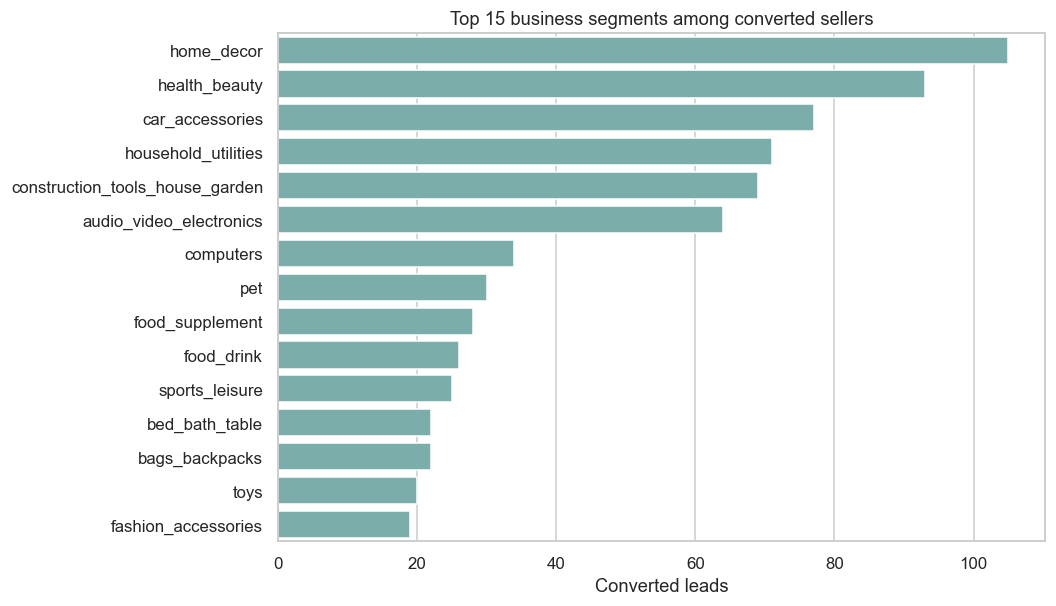

In [7]:
won = leads[leads['is_converted_flag']].copy()

segment_counts = won['business_segment'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=segment_counts.values, y=segment_counts.index, color='#72b7b2', ax=ax)
ax.set(title='Top 15 business segments among converted sellers', xlabel='Converted leads', ylabel='')
save_fig('marketing_segment_volume.png')
plt.show()


**Focused — lead type and business type mix, with median declared revenue**

,converted_leads,leads_with_declared_revenue,median_declared_revenue,median_time_to_win
lead_type,,,,
online_medium,332,17,"20,000.00",12.00
online_big,126,8,"165,000.00",13.00
industry,123,5,"100,000.00",15.00
offline,104,5,"60,000.00",16.00
online_small,77,5,"130,000.00",17.00
online_beginner,57,2,503.00,13.00
online_top,14,0,NaN,6.00
other,3,3,"120,000.00",260.00


,converted_leads,leads_with_declared_revenue,median_declared_revenue
business_type,,,
reseller,587,35,"30,000.00"
manufacturer,242,7,"120,000.00"
other,3,3,"120,000.00"


C:\Users\anshr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\anshr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\anshr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\anshr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_cat

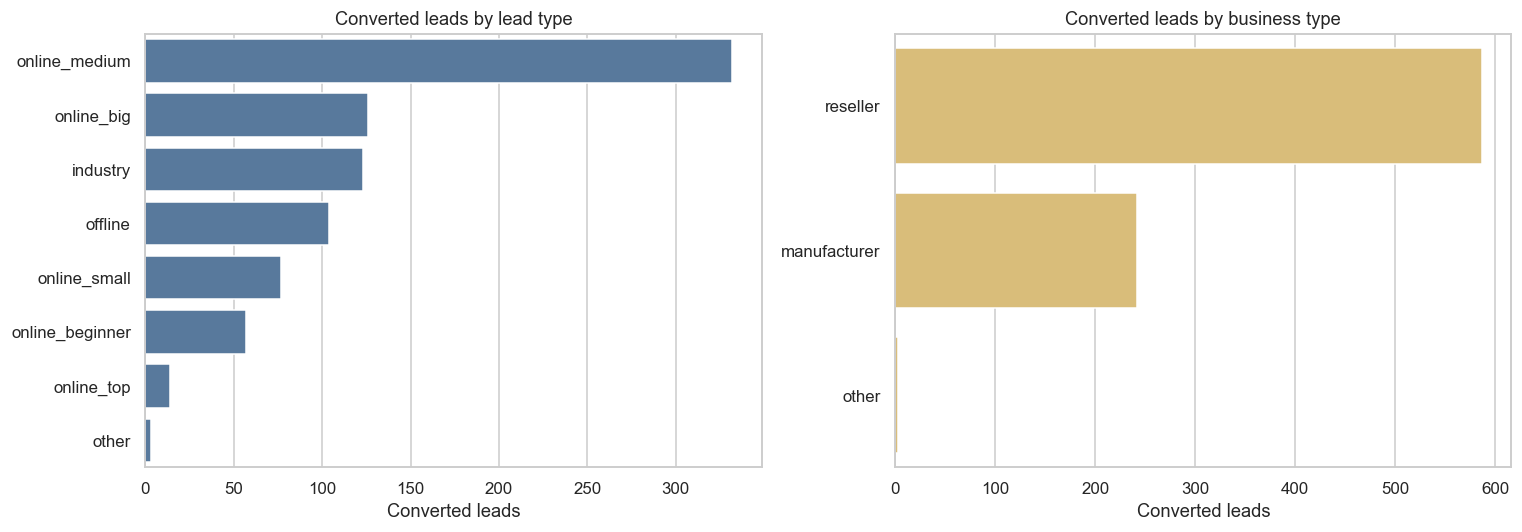

In [8]:
lead_type_view = (won.groupby('lead_type')
    .agg(converted_leads=('mql_id', 'count'),
         leads_with_declared_revenue=('has_declared_revenue', 'sum'),
         median_declared_revenue=('declared_monthly_revenue', 'median'),
         median_time_to_win=('time_to_win_days', 'median'))
    .sort_values('converted_leads', ascending=False))
display(lead_type_view)

business_type_view = (won.groupby('business_type')
    .agg(converted_leads=('mql_id', 'count'),
         leads_with_declared_revenue=('has_declared_revenue', 'sum'),
         median_declared_revenue=('declared_monthly_revenue', 'median'))
    .sort_values('converted_leads', ascending=False))
display(business_type_view)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=lead_type_view.reset_index(), y='lead_type', x='converted_leads',
            color='#4c78a8', ax=axes[0])
axes[0].set(title='Converted leads by lead type', xlabel='Converted leads', ylabel='')
sns.barplot(data=business_type_view.reset_index(), y='business_type', x='converted_leads',
            color='#e9c46a', ax=axes[1])
axes[1].set(title='Converted leads by business type', xlabel='Converted leads', ylabel='')
plt.tight_layout()
save_fig('marketing_lead_business_type.png')
plt.show()


`online_medium` is the largest single lead-type segment among converted sellers, and
`reseller` dominates `business_type` roughly 2:1 over `manufacturer`. This matches the marketplace's
description as a platform for small/medium resellers rather than large manufacturers — useful context
when the dashboard breaks seller performance down by these same categories. Note `median_declared_revenue`
above is now computed only over the ~5% of deals with a real declaration (post-cleaning); most
per-segment cells are based on single-digit sample counts (`leads_with_declared_revenue`), so treat
those medians as illustrative, not a reliable segment comparison.

## 4. Time to win: how long does closing a lead take?

`time_to_win_days` is only defined for converted leads (days between first contact and the deal
being won). The one invalid (negative) value flagged in Section 1 is excluded here via
`time_to_win_valid_flag`.

C:\Users\anshr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\anshr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\anshr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


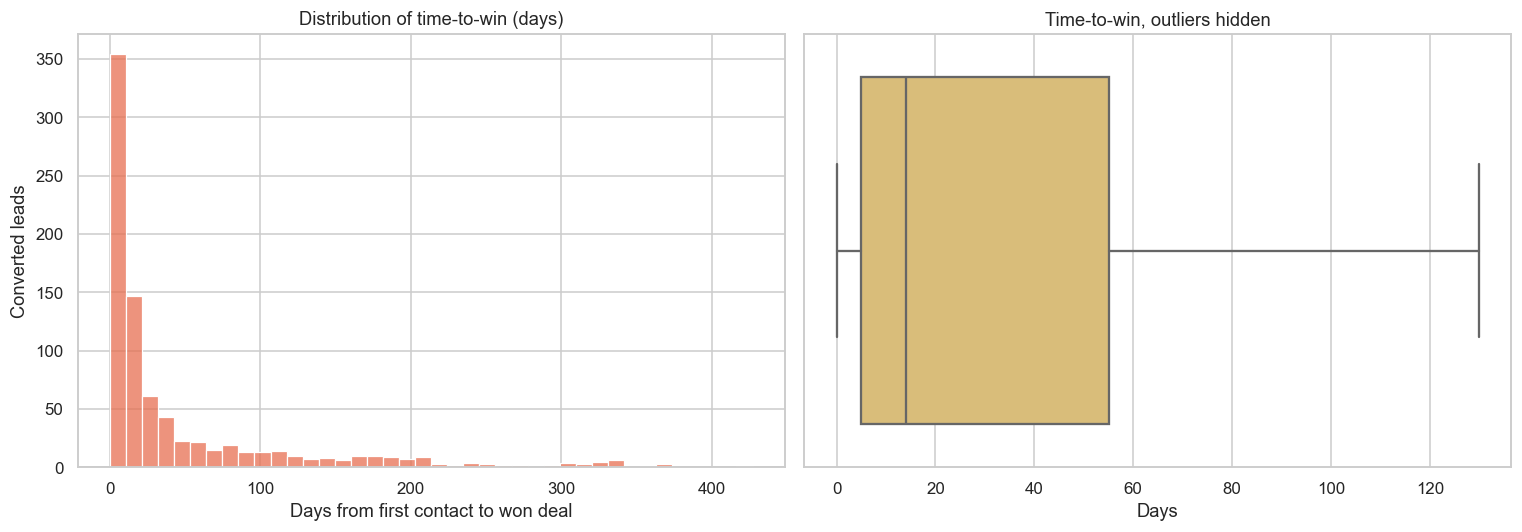

count   841.00
mean     48.50
std      75.35
min       0.00
25%       5.00
50%      14.00
75%      55.00
max     427.00
Name: time_to_win_days, dtype: float64


In [9]:
ttw = won.loc[won['time_to_win_valid_flag'], 'time_to_win_days']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(ttw, bins=40, color='#e76f51', ax=axes[0])
axes[0].set(title='Distribution of time-to-win (days)', xlabel='Days from first contact to won deal',
            ylabel='Converted leads')
sns.boxplot(x=ttw, color='#e9c46a', showfliers=False, ax=axes[1])
axes[1].set(title='Time-to-win, outliers hidden', xlabel='Days')
plt.tight_layout()
save_fig('marketing_time_to_win.png')
plt.show()

print(ttw.describe())


**Focused — time-to-win by lead type**

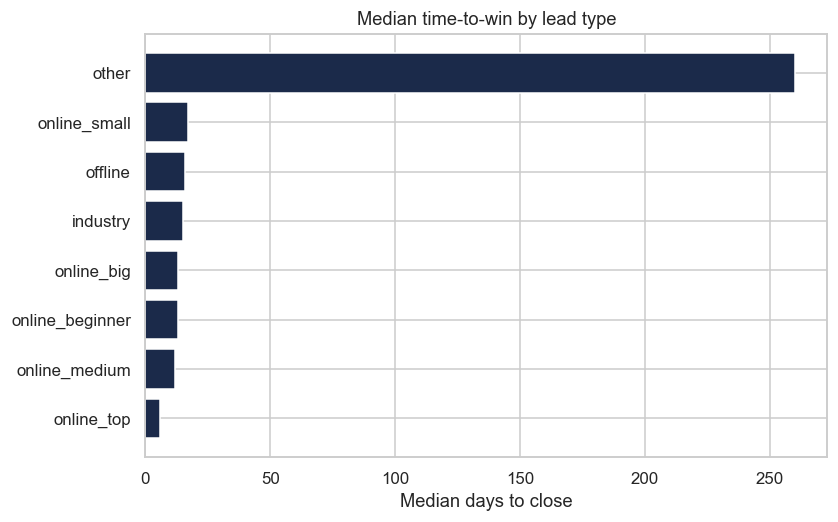

In [10]:
ttw_by_type = (won.loc[won['time_to_win_valid_flag']]
    .groupby('lead_type')['time_to_win_days']
    .median()
    .sort_values())

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(ttw_by_type.index, ttw_by_type.values, color=PALETTE['navy'])
ax.set(title='Median time-to-win by lead type', xlabel='Median days to close', ylabel='')
save_fig('marketing_time_to_win_by_type.png')
plt.show()


Median time-to-win across all converted leads is about two weeks, but the distribution is
right-skewed with a long tail past 100+ days — a small group of leads take far longer to close than
the rest, which matters for sales-capacity planning (a handful of "stuck" leads occupy SDR/SR
attention disproportionately).

## 5. Lead age & recency

`lead_age_days` (days since first contact, computed as of the data extract date) shows how "old"
each lead is regardless of conversion — useful to check whether unconverted leads are simply too
recent to have converted yet, versus genuinely stalled.

C:\Users\anshr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\anshr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\anshr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
C:\Users\anshr\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_cat

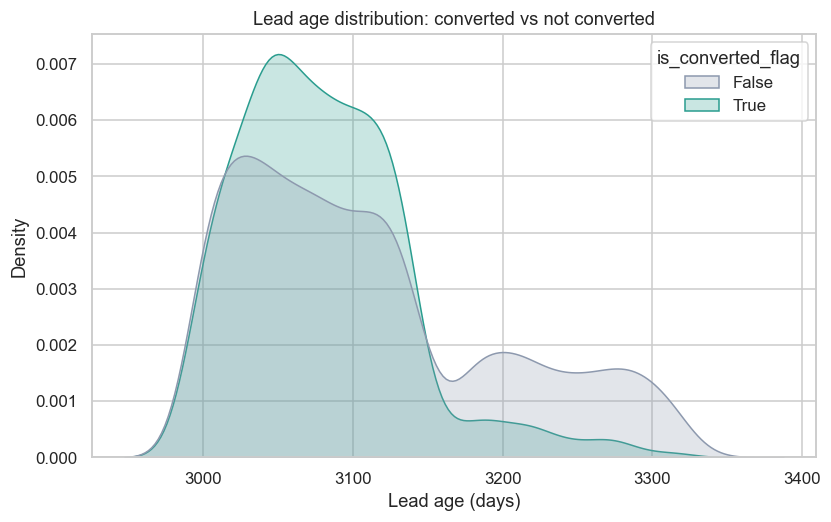

                     count     mean   std      min      25%      50%      75%  \
is_converted_flag                                                               
False             7,158.00 3,109.64 87.84 2,992.00 3,038.00 3,090.00 3,166.00   
True                842.00 3,078.85 55.89 2,992.00 3,037.25 3,072.00 3,112.00   

                       max  
is_converted_flag           
False             3,343.00  
True              3,316.00  


In [11]:
fig, ax = plt.subplots(figsize=(8.5, 5))
sns.kdeplot(data=leads, x='lead_age_days', hue='is_converted_flag', fill=True,
            common_norm=False, palette=[PALETTE['grey'], PALETTE['green']], ax=ax)
ax.set(title='Lead age distribution: converted vs not converted', xlabel='Lead age (days)')
save_fig('marketing_lead_age.png')
plt.show()

print(leads.groupby('is_converted_flag')['lead_age_days'].describe())


Converted and unconverted leads have very similar age distributions (all leads are 3,000+
days old, i.e. the source data itself is a fixed historical extract) — so the low overall conversion
rate (10.5%) is not an artifact of leads being "too new to convert yet"; it reflects the actual funnel.

## 6. Relationship overview (correlations, converted leads only)

A directional diagnostic among the converted-lead numeric fields — guides follow-up questions,
not causal claims. `declared_product_catalog_size` and `declared_monthly_revenue` are now the
cleaned (post-placeholder-removal) values, so this correlation is computed over the ~45-69 deals
with a real declaration, not the full 842 — small sample, read directionally only.

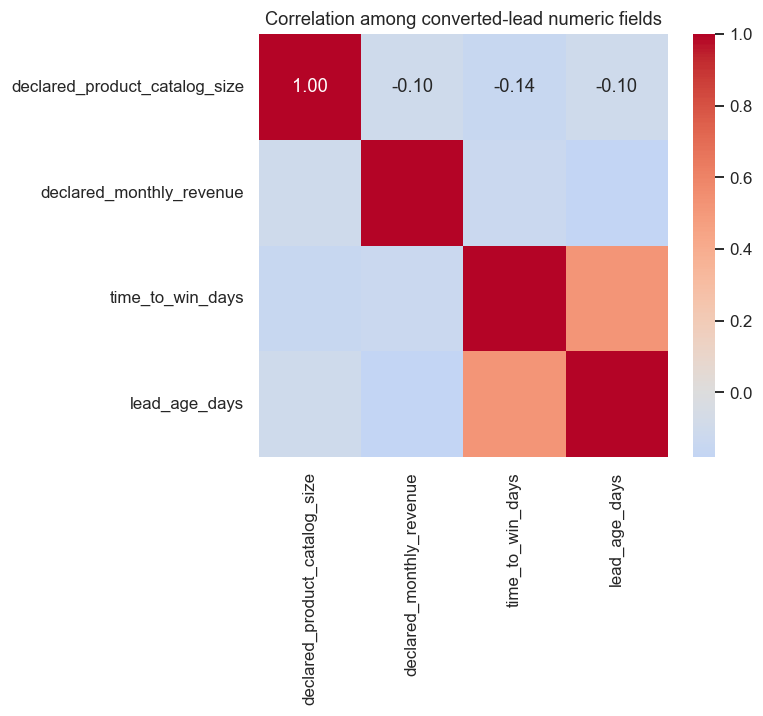

In [12]:
correlation_columns = ['declared_product_catalog_size', 'declared_monthly_revenue',
                       'time_to_win_days', 'lead_age_days']
correlation = won.loc[won['time_to_win_valid_flag'], correlation_columns].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation among converted-lead numeric fields')
save_fig('marketing_correlation.png')
plt.show()


## 7. Takeaways, actions & open questions

**Auto-generated headline numbers (from the cells above)**

In [13]:
best_origin = origin_view['conversion_rate'].idxmax()
best_origin_rate = origin_view['conversion_rate'].max()
top_lead_type = lead_type_view['converted_leads'].idxmax()
median_ttw_days = ttw.median()
reseller_share = business_type_view.loc['reseller', 'converted_leads'] / business_type_view['converted_leads'].sum()

print(f'Overall conversion rate: {conversion_rate:.1%}')
print(f'Best-converting tracked channel: {best_origin} ({best_origin_rate:.1%})')
print(f'Largest converted lead-type segment: {top_lead_type}')
print(f'Median time-to-win: {median_ttw_days:.0f} days')
print(f'Reseller share of converted business_type: {reseller_share:.1%}')


Overall conversion rate: 10.5%
Best-converting tracked channel: unknown_missing (23.3%)
Largest converted lead-type segment: online_medium
Median time-to-win: 14 days
Reseller share of converted business_type: 70.6%


**Findings**

1. **Low overall conversion (~10.5%), and it isn't a recency artifact.** Converted and
   unconverted leads have near-identical age distributions, so the ~90% that don't convert are
   genuinely lost, not merely "not yet closed."
2. **Channel quality varies far more than channel volume.** `paid_search` and `organic_search`
   bring the most leads, but `unknown`/untracked referral sources and `paid_search` convert best;
   `social` and `email` carry real volume (300+ leads each) yet convert well below the platform
   average — a clear target for either better qualification or a different follow-up approach.
3. **The funnel feeds a reseller-dominated marketplace.** Converted leads skew heavily toward
   `reseller` business type (~2:1 over `manufacturer`) and `online_medium` lead type, consistent
   with the platform's stated role of connecting small/medium sellers rather than large brands.
4. **Closing is fast for most, slow for a few.** Median time-to-win is about two weeks, but a
   long right tail (100+ days) suggests a small subset of stuck leads worth tracking separately
   in sales-ops reporting rather than blending into the overall average.
5. **One data-entry issue found and isolated.** A single converted lead has a negative
   time-to-win (won before first contact was logged) — excluded from time-to-win statistics
   rather than silently left in or dropped from the underlying table.
6. **Declared revenue/catalog size are mostly unanswered, not zero.** ~95% of converted deals
   showed `declared_monthly_revenue == 0` uniformly across every lead type — the signature of an
   unfilled survey field, not real data. The cleaning notebook recoded these to `NaN` with explicit
   `has_declared_revenue` / `has_declared_catalog_size` flags; only ~5-8% of converted deals carry
   a usable value, so any revenue-based segment comparison here is illustrative, not conclusive.

**Open questions for the combined analysis**
- Do leads that convert faster end up as better sellers (higher review score, lower
  late-delivery rate) once joined to the seller-level table via `seller_id`? This notebook doesn't
  join to seller outcomes — that link is the natural next step connecting acquisition quality to
  the customer-experience story.
- Is the `unknown` origin's high conversion rate a real channel effect, or a proxy for something
  else (e.g. direct referral from an existing high-quality seller)? Worth checking with whoever
  owns the tracking setup before using it to justify budget shifts.


## Reporting guidance & limitations

Tell an acquisition-funnel story: channel volume and channel quality are not the same thing, the
seller base being reseller-heavy is a structural fact (not a targeting failure), and time-to-win
has a long tail worth monitoring operationally.

*Limitations:* this is a fixed historical extract (leads are already 3,000+ days old at time of
first contact in the data), so it describes completed past behaviour, not live funnel health.
Deal-side attributes (segment, lead type, business type) are only observed for leads that already
converted, so they describe won deals, not what predicts winning — a lead-scoring model would
need lost-lead attributes that this table does not carry.